#Insight - Questão 13

A análise mostra que determinados gêneros possuem forte presença tanto em filmes quanto em séries.

Essa informação pode auxiliar decisões relacionadas a aquisição de conteúdo e estratégia de catálogo.

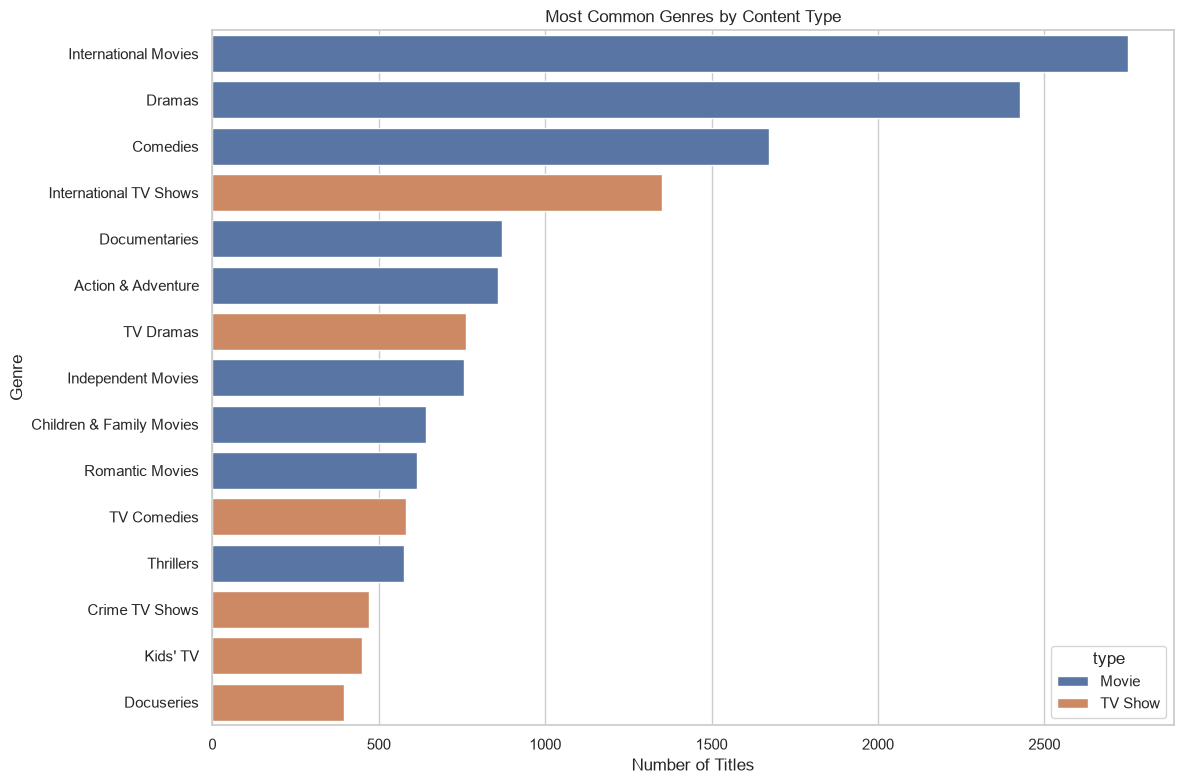

In [6]:
#Questão 13 - Código
#Separando gêneros
genre_df = df[
    [
        "type",
        "listed_in"
    ]
].copy()

genre_df["listed_in"] = (
    genre_df["listed_in"]
    .str.split(", ")
)

genre_df = genre_df.explode(
    "listed_in"
)

genre_df.head()

#Contagem por gênero
genre_type = (
    genre_df
    .groupby(
        [
            "type",
            "listed_in"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
)

genre_type.head()

#Principais gêneros
top_genres = (
    genre_type
    .sort_values(
        "count",
        ascending=False
    )
    .head(15)
)

top_genres

#Gráfico
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_genres,
    x="count",
    y="listed_in",
    hue="type"
)

plt.title(
    "Most Common Genres by Content Type"
)

plt.xlabel(
    "Number of Titles"
)

plt.ylabel(
    "Genre"
)

plt.tight_layout()

plt.savefig(
    "../images/top_genres_by_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Questão 13
- Quais gêneros aparecem mais em filmes e séries?

#Insight - Questão12

- A distribuição de duração apresenta alguns valores extremos.

Esses registros devem ser investigados individualmente antes de qualquer remoção, pois podem representar conteúdos legítimos e não necessariamente erros.

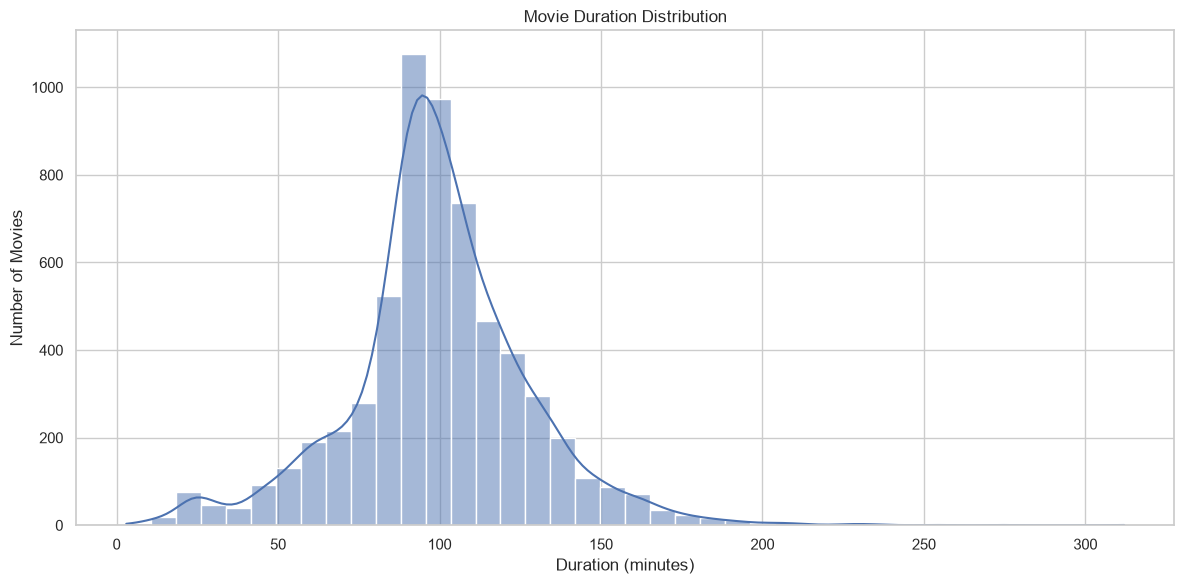

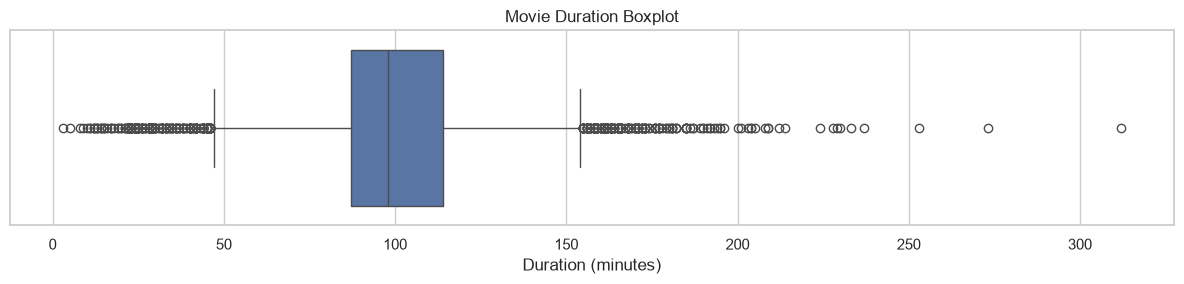

Lower limit: 46.5
Upper limit: 154.5


,title,duration_minutes
22,Avvai Shanmughi,161
24,Jeans,166
73,King of Boys,182
166,Once Upon a Time in America,229
177,The Guns of Navarone,156
202,Kyaa Kool Hai Hum,165
341,Magnolia,189
392,Django Unchained,165
564,Boogie Nights,155
687,Jagame Thandhiram,159


In [10]:
#Questão 12 - criando variável
movies = (
    df[
        df["type"] == "Movie"
    ]
    .copy()
)

#Extraindo minutos
movies["duration_minutes"] = pd.to_numeric(
    movies["duration"]
    .str.replace(
        " min",
        "",
        regex=False
    ),
    errors="coerce"
)

movies = movies.dropna(subset=["duration_minutes"])

movies["duration_minutes"] = (
    movies["duration_minutes"]
    .astype(int)
)

#Estatísticas
movies["duration_minutes"].describe()

#Gráfico - Histograma
plt.figure(figsize=(12,6))

sns.histplot(
    data=movies,
    x="duration_minutes",
    bins=40,
    kde=True
)

plt.title(
    "Movie Duration Distribution"
)

plt.xlabel(
    "Duration (minutes)"
)

plt.ylabel(
    "Number of Movies"
)

plt.tight_layout()

plt.savefig(
    "../images/movie_duration_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Gráfico - Boxplot
plt.figure(figsize=(12,3))

sns.boxplot(
    data=movies,
    x="duration_minutes"
)

plt.title(
    "Movie Duration Boxplot"
)

plt.xlabel(
    "Duration (minutes)"
)

plt.tight_layout()

plt.savefig(
    "../images/movie_duration_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Cálculo de outliers
Q1 = movies["duration_minutes"].quantile(0.25)

Q3 = movies["duration_minutes"].quantile(0.75)

IQR = Q3 - Q1

IQR

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

print(
    f"Lower limit: {lower_limit}"
)

print(
    f"Upper limit: {upper_limit}"
)

#Filmes nos outliers

duration_outliers = movies[
    movies["duration_minutes"] > upper_limit
]

duration_outliers[
    [
        "title",
        "duration_minutes"
    ]
].head(20)

#Questão12
- Qual é a distribuição da duração dos filmes?

##Insight Questão 11

Embora os filmes representem a maior parte do catálogo, observa-se crescimento significativo da quantidade de séries adicionadas ao longo dos anos.

Isso indica uma mudança estratégica da Netflix em direção a conteúdos seriados e produções originais.

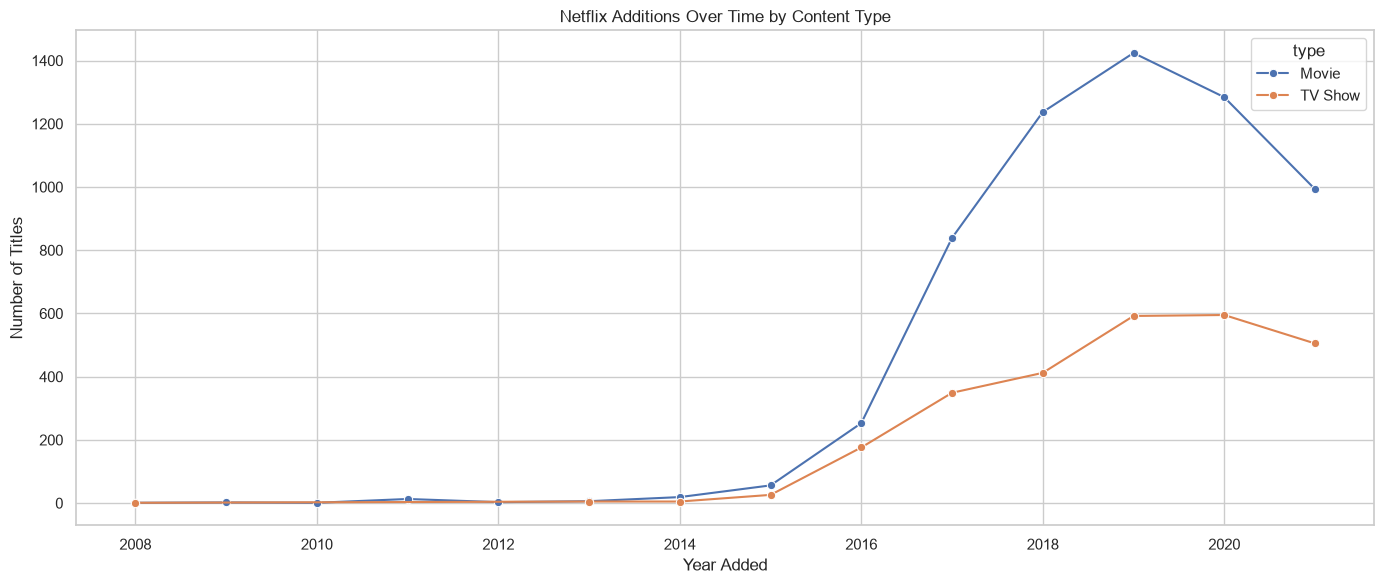

In [4]:
#Questão 11 - preparar dados
year_type = (
    df
    .groupby(
        [
            "year_added",
            "type"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
)

year_type.head()

#Visualização
plt.figure(figsize=(14,6))

sns.lineplot(
    data=year_type,
    x="year_added",
    y="count",
    hue="type",
    marker="o"
)

plt.title(
    "Netflix Additions Over Time by Content Type"
)

plt.xlabel(
    "Year Added"
)

plt.ylabel(
    "Number of Titles"
)

plt.tight_layout()

plt.savefig(
    "../images/content_growth_by_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Questão 11
- A Netflix possui mais filmes ou séries em cada período?

#Objetivo
Entender a evolução histórica.

#Hipótese
Filmes dominaram o catálogo durante todo o período, mas séries cresceram proporcionalmente.

In [3]:
#Importar dados
DATASET_PATH = "../data/processed/netflix_clean.csv"

df = pd.read_csv(
    DATASET_PATH,
    parse_dates=["date_added"]
)

In [8]:
#Configurar ambiente
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

pd.set_option(
    "display.max_columns",
    100
)

#6 — Further Advanced Analysis

- Estatística descritiva
- Distribuições
- Outliers
- Transformações de dados
- Comparações entre grupos

#Análises Avançadas, Distribuições e Outliers

#Objetivo
- Nesta etapa vamos aprofundar a análise estatística dos dados.

#Quetões:
- Existe diferença entre filmes e séries no catálogo?
- Qual é a distribuição de duração dos filmes?
- Existem filmes com duração incomum (outliers)?
- Quais gêneros aparecem com maior frequência por tipo de conteúdo?
- Quais atores aparecem mais vezes no catálogo?
- Como o catálogo evoluiu considerando filmes e séries separadamente?